# Image Captioning: Data Loading, Training & Inference Demo

This notebook is fully self-contained — no external `models.py` or `src/` folder
required. Everything (encoder, attention, decoder, training loop, and an
inference demo) lives in this single notebook so it runs top-to-bottom with
**Run All** on Kaggle.

## Architecture

| Component | Choice | Why |
|---|---|---|
| Encoder | **EfficientNet-B4** (ImageNet pretrained) | Stronger, more efficient features than ResNet-50 at similar cost |
| Decoder | **LSTM** | Kept as requested |
| Attention | **Multi-head cross-attention** (8 heads) | Replaces single-head Bahdanau attention — different heads can specialise on different image regions per decoding step |
| Positional encoding | 2D sinusoidal, added to spatial features | Gives attention an explicit sense of *where* each feature vector sits in the image |
| Weight tying | Embedding ↔ output projection share weights | Standard trick, fewer params, usually better generation |
| Scheduled sampling | Teacher-forcing ratio decays over training | Reduces train/inference mismatch (exposure bias) |
| Decoding | Beam search (inference) | Better caption quality than greedy decoding |

## Before running

**Enable internet** in the notebook settings panel (right sidebar → Internet: On).
The first run needs to download ImageNet-pretrained EfficientNet-B4 weights (~75MB).

**Attach the dataset**: use *Add Input* → your `caption_data` dataset (containing
`captions.txt` and an `Images/` folder of images). The notebook automatically
searches `/kaggle/input` for these files — no manual path editing needed.

Then just click **Run All**.


## 1. Setup & Imports

In [1]:
import os
import re
import json
import glob
import math
import random
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

WORK_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
MODEL_DIR = os.path.join(WORK_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)
print("Model artifacts will be saved to:", MODEL_DIR)


Using device: cuda
Model artifacts will be saved to: /kaggle/working/models


## 2. Locate the dataset

Searches `/kaggle/input` (and a couple of local fallback locations) for
`captions.txt` and the matching `Images/` folder, so you don't have to hardcode
paths. Also handles the case where the zip wasn't auto-extracted.

In [2]:
def find_dataset():
    search_roots = ["/kaggle/input", "../data/caption_data", "./caption_data", "."]

    # 1) Look for an already-extracted captions.txt
    for root in search_roots:
        if not os.path.exists(root):
            continue
        matches = glob.glob(os.path.join(root, "**", "captions.txt"), recursive=True)
        if matches:
            captions_file = matches[0]
            base_dir = os.path.dirname(captions_file)
            # Images folder is usually a sibling directory
            img_candidates = [d for d in glob.glob(os.path.join(base_dir, "*"))
                               if os.path.isdir(d) and "image" in os.path.basename(d).lower()]
            if not img_candidates:
                # search one level up / down for an Images-like folder
                img_candidates = [d for d in glob.glob(os.path.join(base_dir, "**"), recursive=True)
                                   if os.path.isdir(d) and "image" in os.path.basename(d).lower()]
            images_dir = img_candidates[0] if img_candidates else os.path.join(base_dir, "Images")
            return captions_file, images_dir

    # 2) Fallback: an un-extracted zip somewhere under /kaggle/input
    zip_matches = glob.glob("/kaggle/input/**/*.zip", recursive=True)
    if zip_matches:
        extract_to = os.path.join(WORK_DIR, "caption_data_extracted")
        os.makedirs(extract_to, exist_ok=True)
        print(f"Found zip {zip_matches[0]}, extracting to {extract_to} ...")
        with zipfile.ZipFile(zip_matches[0], "r") as zf:
            zf.extractall(extract_to)
        matches = glob.glob(os.path.join(extract_to, "**", "captions.txt"), recursive=True)
        if matches:
            captions_file = matches[0]
            base_dir = os.path.dirname(captions_file)
            img_candidates = [d for d in glob.glob(os.path.join(base_dir, "**"), recursive=True)
                               if os.path.isdir(d) and "image" in os.path.basename(d).lower()]
            images_dir = img_candidates[0] if img_candidates else os.path.join(base_dir, "Images")
            return captions_file, images_dir

    raise FileNotFoundError(
        "Could not find captions.txt anywhere under /kaggle/input. "
        "Make sure the caption_data dataset is attached via 'Add Input'."
    )

captions_file, images_dir = find_dataset()
print("captions.txt ->", captions_file)
print("Images dir    ->", images_dir)
assert os.path.exists(captions_file), "captions.txt not found"
assert os.path.isdir(images_dir), "Images directory not found"


captions.txt -> /kaggle/input/datasets/mariamromelashvili/caption-data/captions.txt
Images dir    -> /kaggle/input/datasets/mariamromelashvili/caption-data/Images


## 3. Data Loading & Preprocessing

In [3]:
df = pd.read_csv(captions_file)
print(f"Total caption-image pairs: {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
print(df.head(10))


Total caption-image pairs: 40455
Unique images: 8091
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   
5  1001773457_577c3a7d70.jpg   
6  1001773457_577c3a7d70.jpg   
7  1001773457_577c3a7d70.jpg   
8  1001773457_577c3a7d70.jpg   
9  1001773457_577c3a7d70.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
5         A black dog and a spotted dog are fighting  
6  A black dog and a tri-colored dog playing with...  
7  A black dog and a white dog with brown spots a...  
8  Two dogs of different breeds looking at each o...  
9    Two dogs on pavement moving toward each

In [4]:
def preprocess_caption(caption):
    """Clean and normalize caption text"""
    caption = caption.lower()
    caption = re.sub(r'[^a-z0-9\s.,]', '', caption)
    caption = '<start> ' + caption + ' <end>'
    return caption

df['caption'] = df['caption'].apply(preprocess_caption)
print("Sample preprocessed captions:")
print(df['caption'].head())


Sample preprocessed captions:
0    <start> a child in a pink dress is climbing up...
1    <start> a girl going into a wooden building . ...
2    <start> a little girl climbing into a wooden p...
3    <start> a little girl climbing the stairs to h...
4    <start> a little girl in a pink dress going in...
Name: caption, dtype: object


In [5]:
def build_vocab(captions, min_freq=2):
    """Build vocabulary from captions"""
    word_counts = Counter()
    for caption in captions:
        words = caption.split()
        word_counts.update(words)
    special_tokens = {'<pad>', '<start>', '<end>', '<unk>'}
    vocab = {'<pad>': 0, '<start>': 1, '<end>': 2, '<unk>': 3}
    idx = 4
    for word, count in word_counts.items():
        if count >= min_freq and word not in special_tokens:
            vocab[word] = idx
            idx += 1
    return vocab

vocab = build_vocab(df['caption'].values)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")
print(f"Special tokens: <pad>={vocab['<pad>']}, <start>={vocab['<start>']}, <end>={vocab['<end>']}, <unk>={vocab['<unk>']}")


Vocabulary size: 5226
Special tokens: <pad>=0, <start>=1, <end>=2, <unk>=3


In [6]:
vocab_path = os.path.join(MODEL_DIR, "vocab.json")
with open(vocab_path, 'w') as f:
    json.dump(vocab, f)
print(f"Vocabulary saved to {vocab_path}")
idx_to_word = {idx: word for word, idx in vocab.items()}


Vocabulary saved to /kaggle/working/models/vocab.json


In [7]:
class ImageCaptionDataset(Dataset):
    def __init__(self, df, images_dir, vocab, transform=None, max_length=25):
        self.df = df
        self.images_dir = images_dir
        self.vocab = vocab
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row['image']
        caption = row['caption']
        image_path = os.path.join(self.images_dir, image_name)
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        caption_words = caption.split()
        caption_indices = [self.vocab.get(word, self.vocab['<unk>']) for word in caption_words]
        if len(caption_indices) > self.max_length:
            if caption_indices[0] == self.vocab['<start>']:
                caption_indices = [caption_indices[0]] + caption_indices[1:self.max_length-1] + [self.vocab['<end>']]
            else:
                caption_indices = caption_indices[:self.max_length-1] + [self.vocab['<end>']]
        return image, torch.tensor(caption_indices, dtype=torch.long)


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

max_caption_length = 25
dataset = ImageCaptionDataset(df, images_dir, vocab, transform=train_transform, max_length=max_caption_length)
print(f"Dataset size: {len(dataset)}")
sample_image, sample_caption = dataset[0]
print(f"Image shape: {sample_image.shape}")
print(f"Caption indices: {sample_caption[:10]}")


Dataset size: 40455
Image shape: torch.Size([3, 224, 224])
Caption indices: tensor([ 1,  4,  5,  6,  4,  7,  8,  9, 10, 11])


In [9]:
def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images, 0)
    max_len = max(len(cap) for cap in captions)
    padded_captions = []
    for cap in captions:
        pad_length = max_len - len(cap)
        padded_cap = torch.cat([cap, torch.zeros(pad_length, dtype=torch.long)])
        padded_captions.append(padded_cap)
    captions = torch.stack(padded_captions, 0)
    return images, captions

unique_images = df['image'].unique()
np.random.shuffle(unique_images)
n_train = int(0.8 * len(unique_images))
n_val = int(0.1 * len(unique_images))
train_images = set(unique_images[:n_train])
val_images = set(unique_images[n_train:n_train+n_val])
test_images = set(unique_images[n_train+n_val:])

train_df = df[df['image'].isin(train_images)].reset_index(drop=True)
val_df = df[df['image'].isin(val_images)].reset_index(drop=True)
test_df = df[df['image'].isin(test_images)].reset_index(drop=True)

print(f"Train: {len(train_df)} samples, {len(train_images)} images")
print(f"Val:   {len(val_df)} samples, {len(val_images)} images")
print(f"Test:  {len(test_df)} samples, {len(test_images)} images")


Train: 32360 samples, 6472 images
Val:   4045 samples, 809 images
Test:  4050 samples, 810 images


In [10]:
batch_size = 16
max_caption_length = 25

train_dataset = ImageCaptionDataset(train_df, images_dir, vocab, train_transform, max_length=max_caption_length)
val_dataset = ImageCaptionDataset(val_df, images_dir, vocab, val_transform, max_length=max_caption_length)
test_dataset = ImageCaptionDataset(test_df, images_dir, vocab, val_transform, max_length=max_caption_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=2)
print("DataLoaders ready.")


DataLoaders ready.


## 4. Model Definition

Encoder-decoder architecture:
- **Encoder**: EfficientNet-B4 CNN (ImageNet pretrained), projected to a spatial
  feature grid with 2D positional encoding added on top.
- **Decoder**: LSTM, driven at every step by an 8-head cross-attention block
  over the image's spatial features (instead of the original single-head
  Bahdanau attention).

In [11]:
class EfficientNetEncoder(nn.Module):
    """CNN encoder based on EfficientNet-B4 (replaces ResNet-50).

    EfficientNet-B4 gives richer ImageNet features than ResNet-50 at a
    comparable or lower parameter budget. We keep the spatial feature map
    (instead of pooling straight to a single vector) so the decoder's
    attention can look at different image regions.
    """
    def __init__(self, encoder_dim=512, pool_size=7):
        super().__init__()
        weights = models.EfficientNet_B4_Weights.IMAGENET1K_V1
        effnet = models.efficientnet_b4(weights=weights)
        self.features = effnet.features                     # -> (batch, 1792, h, w)
        self.pool = nn.AdaptiveAvgPool2d((pool_size, pool_size))
        # Project 1792 -> encoder_dim. Kept larger (512) than a typical 256
        # bottleneck so less visual detail is thrown away before attention.
        self.projection = nn.Linear(1792, encoder_dim)
        self.encoder_dim = encoder_dim
        self.pool_size = pool_size
        self.fine_tune(False)

    def forward(self, images):
        feats = self.features(images)            # (batch, 1792, h, w)
        feats = self.pool(feats)                  # (batch, 1792, pool, pool)
        feats = feats.permute(0, 2, 3, 1)         # (batch, pool, pool, 1792)
        batch, h, w, c = feats.shape
        feats = feats.reshape(batch, h * w, c)    # (batch, num_pixels, 1792)
        feats = self.projection(feats)            # (batch, num_pixels, encoder_dim)
        return feats, h, w

    def fine_tune(self, fine_tune=True, num_trainable_blocks=3):
        for p in self.features.parameters():
            p.requires_grad = False
        if fine_tune:
            trainable_children = list(self.features.children())[-num_trainable_blocks:]
            for child in trainable_children:
                for p in child.parameters():
                    p.requires_grad = True
        self.fine_tune_enabled = fine_tune


In [12]:
class PositionalEncoding2D(nn.Module):
    """Fixed sinusoidal 2D positional encoding added to the spatial feature grid.

    Without this, attention has no explicit notion of *where* a feature
    vector sits in the image (top-left vs. bottom-right), which makes it
    harder to learn spatial relations like 'next to' or 'above'.
    """
    def __init__(self, dim, max_h=20, max_w=20):
        super().__init__()
        assert dim % 4 == 0, "encoder_dim must be divisible by 4"
        self.dim = dim
        d_quarter = dim // 4
        div_term = torch.exp(torch.arange(0, d_quarter, dtype=torch.float32) * (-math.log(10000.0) / d_quarter))
        pos_h = torch.arange(max_h, dtype=torch.float32).unsqueeze(1)
        pos_w = torch.arange(max_w, dtype=torch.float32).unsqueeze(1)
        pe_h_sin = torch.sin(pos_h * div_term)
        pe_h_cos = torch.cos(pos_h * div_term)
        pe_w_sin = torch.sin(pos_w * div_term)
        pe_w_cos = torch.cos(pos_w * div_term)
        pe = torch.zeros(max_h, max_w, dim)
        pe[:, :, 0*d_quarter:1*d_quarter] = pe_h_sin.unsqueeze(1).expand(max_h, max_w, d_quarter)
        pe[:, :, 1*d_quarter:2*d_quarter] = pe_h_cos.unsqueeze(1).expand(max_h, max_w, d_quarter)
        pe[:, :, 2*d_quarter:3*d_quarter] = pe_w_sin.unsqueeze(0).expand(max_h, max_w, d_quarter)
        pe[:, :, 3*d_quarter:4*d_quarter] = pe_w_cos.unsqueeze(0).expand(max_h, max_w, d_quarter)
        self.register_buffer("pe", pe)

    def forward(self, x, h, w):
        pos = self.pe[:h, :w, :].reshape(h * w, self.dim).unsqueeze(0)
        return x + pos.to(x.device)


In [13]:
class MultiHeadVisualAttention(nn.Module):
    """Multi-head cross-attention: the decoder's hidden state (query) attends
    over the image's spatial features (keys/values).

    Replaces the original single-head Bahdanau attention. With multiple
    heads, different heads can specialise on different regions or aspects of
    the image at every decoding step (e.g. one head tracking the main
    subject, another the background) instead of forcing everything through
    one attention distribution.
    """
    def __init__(self, encoder_dim, decoder_dim, attn_dim, num_heads=8):
        super().__init__()
        assert attn_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = attn_dim // num_heads
        self.attn_dim = attn_dim
        self.q_proj = nn.Linear(decoder_dim, attn_dim)
        self.k_proj = nn.Linear(encoder_dim, attn_dim)
        self.v_proj = nn.Linear(encoder_dim, attn_dim)
        self.out_proj = nn.Linear(attn_dim, encoder_dim)
        self.scale = self.head_dim ** -0.5

    def forward(self, encoder_out, decoder_hidden):
        batch = encoder_out.size(0)
        num_pixels = encoder_out.size(1)
        q = self.q_proj(decoder_hidden).view(batch, self.num_heads, 1, self.head_dim)
        k = self.k_proj(encoder_out).view(batch, num_pixels, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(encoder_out).view(batch, num_pixels, self.num_heads, self.head_dim).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale     # (batch, heads, 1, num_pixels)
        alpha = torch.softmax(scores, dim=-1)
        context = torch.matmul(alpha, v)                               # (batch, heads, 1, head_dim)
        context = context.transpose(1, 2).contiguous().view(batch, self.attn_dim)
        context = self.out_proj(context)                                # (batch, encoder_dim)
        alpha_avg = alpha.mean(dim=1).squeeze(1)   # heads averaged, used for attention regularization
        return context, alpha_avg


In [14]:
class DecoderWithMultiHeadAttention(nn.Module):
    """LSTM decoder driven by multi-head cross-attention over image features.

    Includes:
    - a sigmoid gate on the attention context (as in 'Show, Attend and Tell'),
    - weight tying between the input embedding and output projection,
    - scheduled sampling support via `teacher_forcing_ratio`.
    """
    def __init__(self, vocab_size, embed_dim, decoder_dim, attn_dim, encoder_dim, num_heads=8, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.decoder_dim = decoder_dim
        self.embed_dim = embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.attention = MultiHeadVisualAttention(encoder_dim, decoder_dim, attn_dim, num_heads=num_heads)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)   # gating scalar for the attention context
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(decoder_dim, vocab_size)
        # Weight tying: the embedding and output projection share the same
        # weight matrix. Reduces parameters and usually improves generation
        # quality since both layers are learning related word representations.
        if embed_dim == decoder_dim:
            self.fc_out.weight = self.embedding.weight
        self.init_weights()

    def init_weights(self):
        self.embedding.weight.data.uniform_(-0.1, 0.1)
        self.fc_out.bias.data.fill_(0)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, captions, caption_lengths, teacher_forcing_ratio=1.0):
        """teacher_forcing_ratio=1.0 -> always use ground-truth previous word
        (classic teacher forcing). Lower values randomly substitute the
        model's own previous prediction instead (scheduled sampling), which
        narrows the gap between training and free-running inference.
        """
        batch_size = encoder_out.size(0)
        num_pixels = encoder_out.size(1)
        embeddings = self.embedding(captions)
        h, c = self.init_hidden_state(encoder_out)
        decode_lengths = [length - 1 for length in caption_lengths.tolist()]
        max_decode_len = max(decode_lengths)
        predictions = torch.zeros(batch_size, max_decode_len, self.vocab_size, device=encoder_out.device)
        alphas = torch.zeros(batch_size, max_decode_len, num_pixels, device=encoder_out.device)

        for t in range(max_decode_len):
            batch_size_t = sum([l > t for l in decode_lengths])
            context, alpha = self.attention(encoder_out[:batch_size_t], h[:batch_size_t])
            gate = self.sigmoid(self.f_beta(h[:batch_size_t]))
            context = gate * context

            use_teacher = (t == 0) or (torch.rand(1).item() < teacher_forcing_ratio)
            if use_teacher:
                word_embed = embeddings[:batch_size_t, t, :]
            else:
                with torch.no_grad():
                    prev_ids = predictions[:batch_size_t, t - 1, :].argmax(dim=-1)
                word_embed = self.embedding(prev_ids)

            lstm_input = torch.cat([word_embed, context], dim=1)
            h_t, c_t = self.lstm_cell(lstm_input, (h[:batch_size_t], c[:batch_size_t]))
            if batch_size_t < batch_size:
                h = torch.cat([h_t, h[batch_size_t:]], dim=0)
                c = torch.cat([c_t, c[batch_size_t:]], dim=0)
            else:
                h, c = h_t, c_t
            preds = self.fc_out(self.dropout(h_t))
            predictions[:batch_size_t, t, :] = preds
            alphas[:batch_size_t, t, :] = alpha
        return predictions, captions, decode_lengths, alphas


In [15]:
class ImageCaptionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, decoder_dim, attn_dim, encoder_dim, num_heads=8, dropout=0.3):
        super().__init__()
        self.encoder = EfficientNetEncoder(encoder_dim=encoder_dim)
        self.pos_encoding = PositionalEncoding2D(encoder_dim)
        self.decoder = DecoderWithMultiHeadAttention(
            vocab_size, embed_dim, decoder_dim, attn_dim, encoder_dim,
            num_heads=num_heads, dropout=dropout
        )

    def forward(self, images, captions, caption_lengths, teacher_forcing_ratio=1.0):
        encoder_out, h, w = self.encoder(images)
        encoder_out = self.pos_encoding(encoder_out, h, w)
        return self.decoder(encoder_out, captions, caption_lengths, teacher_forcing_ratio)


In [16]:
embed_dim = 512
decoder_dim = 512
attention_dim = 512
encoder_dim = 512     # raised from a typical 256 bottleneck to keep more visual detail
num_heads = 8
dropout = 0.3

model = ImageCaptionModel(vocab_size, embed_dim, decoder_dim, attention_dim, encoder_dim,
                           num_heads=num_heads, dropout=dropout)
model.encoder.fine_tune(False)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model created with {n_params:,} parameters")
print(f"Trainable parameters: {n_trainable:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 208MB/s]


Model created with 26,135,986 parameters
Trainable parameters: 8,587,370


## 5. Training

In [17]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, smoothing=0.1, ignore_index=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.smoothing = smoothing
        self.ignore_index = ignore_index
        self.confidence = 1.0 - smoothing

    def forward(self, pred, target):
        log_probs = nn.functional.log_softmax(pred, dim=-1)
        true_dist = torch.zeros_like(log_probs)
        true_dist.fill_(self.smoothing / (self.vocab_size - 1))
        true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
        true_dist[:, self.ignore_index] = 0
        mask = (target != self.ignore_index)
        true_dist = true_dist * mask.unsqueeze(1).float()
        return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

criterion = LabelSmoothingLoss(vocab_size, smoothing=0.05, ignore_index=vocab['<pad>'])

decoder_params = list(model.decoder.parameters())
encoder_params = list(model.encoder.parameters())
base_lr_decoder = 0.0005
base_lr_encoder = 0.0001
optimizer = optim.Adam([
    {'params': decoder_params, 'lr': base_lr_decoder},
    {'params': encoder_params, 'lr': base_lr_encoder}
], weight_decay=1e-4)


In [18]:
def train_epoch(model, train_loader, criterion, optimizer, device, alpha_c=0.3, teacher_forcing_ratio=1.0):
    """Train for one epoch with doubly stochastic attention regularization
    and scheduled sampling (teacher_forcing_ratio < 1.0 mixes in the model's
    own predictions)."""
    model.train()
    total_loss = 0
    num_batches = 0
    for images, captions in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        captions = captions.to(device)
        caption_lengths = (captions != vocab['<pad>']).sum(dim=1)
        caption_lengths, sort_idx = caption_lengths.sort(dim=0, descending=True)
        images = images[sort_idx]
        captions = captions[sort_idx]

        predictions, encoded_captions, decode_lengths, alphas = model(
            images, captions, caption_lengths, teacher_forcing_ratio=teacher_forcing_ratio
        )
        targets = encoded_captions[:, 1:]
        predictions = predictions.reshape(-1, vocab_size)
        targets = targets.reshape(-1)
        mask = (targets != vocab['<pad>'])
        predictions = predictions[mask]
        targets = targets[mask]
        loss = criterion(predictions, targets)

        decode_lengths_tensor = torch.tensor(decode_lengths, device=alphas.device)
        max_len = alphas.size(1)
        time_ids = torch.arange(max_len, device=alphas.device).unsqueeze(0)
        att_mask = (time_ids < decode_lengths_tensor.unsqueeze(1)).unsqueeze(2).float()
        alphas_sum = (alphas * att_mask).sum(dim=1)
        att_regularization = alpha_c * ((1. - alphas_sum) ** 2).mean()
        loss = loss + att_regularization

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1
    return total_loss / num_batches


In [19]:
def validate(model, val_loader, criterion, device):
    """Validate the model (teacher_forcing_ratio=1.0, no scheduled sampling
    at validation time so the loss is comparable across epochs)."""
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for images, captions in tqdm(val_loader, desc="Validating"):
            images = images.to(device)
            captions = captions.to(device)
            caption_lengths = (captions != vocab['<pad>']).sum(dim=1)
            caption_lengths, sort_idx = caption_lengths.sort(dim=0, descending=True)
            images = images[sort_idx]
            captions = captions[sort_idx]
            predictions, encoded_captions, decode_lengths, alphas = model(
                images, captions, caption_lengths, teacher_forcing_ratio=1.0
            )
            targets = encoded_captions[:, 1:]
            predictions = predictions.reshape(-1, vocab_size)
            targets = targets.reshape(-1)
            mask = (targets != vocab['<pad>'])
            predictions = predictions[mask]
            targets = targets[mask]
            loss = criterion(predictions, targets)
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches


In [20]:
num_epochs = 25
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 6
patience_counter = 0
unfreeze_encoder_epoch = 5
warmup_epochs = 3
encoder_lr_scale = 0.1

# Scheduled sampling: start at pure teacher forcing (1.0) and gently decay
# to 0.7 by the final epoch. Kept mild since the dataset is modest in size
# (~40k caption rows) and full free-running training can destabilise LSTMs.
min_teacher_forcing = 0.7

print("Starting training...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    if epoch == unfreeze_encoder_epoch and not model.encoder.fine_tune_enabled:
        model.encoder.fine_tune(fine_tune=True, num_trainable_blocks=3)
        print(f"Unfreezing encoder (last 3 blocks) at epoch {epoch}")

    current_encoder_scale = encoder_lr_scale if epoch >= unfreeze_encoder_epoch else 1.0
    if epoch < warmup_epochs:
        warmup_factor = (epoch + 1) / warmup_epochs
        for i, param_group in enumerate(optimizer.param_groups):
            if i == 0:
                param_group['lr'] = base_lr_decoder * warmup_factor
            else:
                param_group['lr'] = base_lr_encoder * warmup_factor * current_encoder_scale
    else:
        progress = (epoch - warmup_epochs) / max(1, (num_epochs - warmup_epochs))
        cosine_factor = 0.5 * (1 + np.cos(np.pi * progress))
        for i, param_group in enumerate(optimizer.param_groups):
            if i == 0:
                param_group['lr'] = base_lr_decoder * cosine_factor
            else:
                param_group['lr'] = base_lr_encoder * cosine_factor * current_encoder_scale

    teacher_forcing_ratio = max(min_teacher_forcing, 1.0 - epoch * ((1.0 - min_teacher_forcing) / num_epochs))

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device,
                              teacher_forcing_ratio=teacher_forcing_ratio)
    train_losses.append(train_loss)
    val_loss = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)

    current_lr_decoder = optimizer.param_groups[0]['lr']
    current_lr_encoder = optimizer.param_groups[1]['lr'] if len(optimizer.param_groups) > 1 else current_lr_decoder
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"TF ratio: {teacher_forcing_ratio:.2f}, "
          f"LR Decoder: {current_lr_decoder:.6f}, LR Encoder: {current_lr_encoder:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': train_loss,
            'vocab': vocab,
            'vocab_size': vocab_size,
            'embed_dim': embed_dim,
            'decoder_dim': decoder_dim,
            'attention_dim': attention_dim,
            'encoder_dim': encoder_dim,
            'num_heads': num_heads,
            'idx_to_word': idx_to_word,
        }, os.path.join(MODEL_DIR, 'best_model.pth'))
        print(f"Saved best model with val loss: {val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping after {epoch+1} epochs")
            break


Starting training...

Epoch 1/25


Validating: 100%|██████████| 253/253 [00:20<00:00, 12.10it/s]


Train Loss: 4.6721, Val Loss: 3.9431, TF ratio: 1.00, LR Decoder: 0.000167, LR Encoder: 0.000033
Saved best model with val loss: 3.9431

Epoch 2/25


Validating: 100%|██████████| 253/253 [00:20<00:00, 12.22it/s]


Train Loss: 4.0080, Val Loss: 3.5793, TF ratio: 0.99, LR Decoder: 0.000333, LR Encoder: 0.000067
Saved best model with val loss: 3.5793

Epoch 3/25


...

Train Loss: 3.7006, Val Loss: 3.3247, TF ratio: 0.81, LR Decoder: 0.000180, LR Encoder: 0.000004

Epoch 18/25


Validating: 100%|██████████| 253/253 [00:20<00:00, 12.26it/s]


Train Loss: 3.7106, Val Loss: 3.3255, TF ratio: 0.80, LR Decoder: 0.000146, LR Encoder: 0.000003

Epoch 19/25


Validating: 100%|██████████| 253/253 [00:20<00:00, 12.24it/s]

Train Loss: 3.7190, Val Loss: 3.3347, TF ratio: 0.78, LR Decoder: 0.000115, LR Encoder: 0.000002
Early stopping after 19 epochs


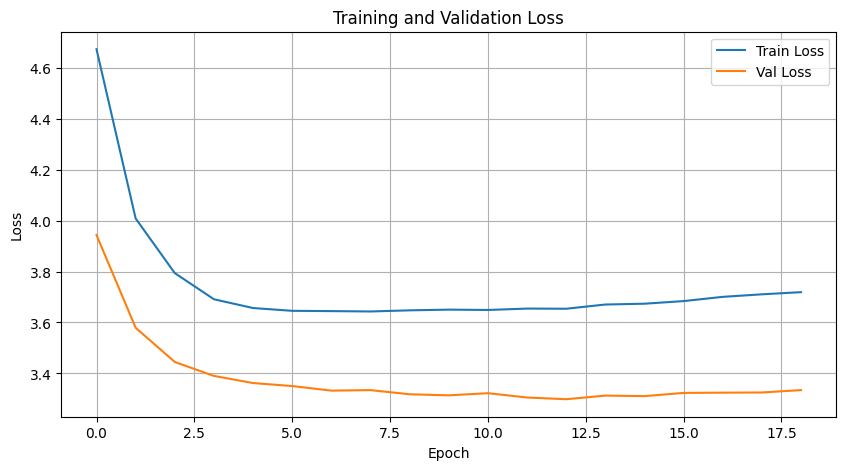

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(MODEL_DIR, 'loss_curve.png'), dpi=150)
plt.show()


## 6. Save Final Model

In [22]:
checkpoint = torch.load(os.path.join(MODEL_DIR, 'best_model.pth'), map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

final_model_path = os.path.join(MODEL_DIR, 'final_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': vocab,
    'vocab_size': vocab_size,
    'embed_dim': embed_dim,
    'decoder_dim': decoder_dim,
    'attention_dim': attention_dim,
    'encoder_dim': encoder_dim,
    'num_heads': num_heads,
    'idx_to_word': idx_to_word,
}, final_model_path)

print(f"Final model saved to {final_model_path}")
print(f"Model trained for {checkpoint['epoch']+1} epochs")
print(f"Best validation loss: {checkpoint['val_loss']:.4f}")


Final model saved to /kaggle/working/models/final_model.pth
Model trained for 13 epochs
Best validation loss: 3.2990


## 7. Inference Demo

Loads the best checkpoint, defines `generate_caption(image_path, model)` using
beam search decoding, then demonstrates it two ways:
1. **Automatic** — captions 4 random test-set images on its own.
2. **Upload** — lets you upload your own image(s) and captions them.

In [23]:
model.eval()

def beam_search_caption(model, encoder_out, beam_width=5, max_len=25, length_penalty=0.7):
    """Beam search decoding: keeps the top-k highest scoring partial
    sequences at every step instead of greedily picking one word, which
    generally produces noticeably better captions than greedy decoding."""
    k = beam_width
    enc_dim = encoder_out.size(-1)
    num_pixels = encoder_out.size(1)
    encoder_out = encoder_out.expand(k, num_pixels, enc_dim)

    start_idx = vocab['<start>']
    end_idx = vocab['<end>']
    vsize = model.decoder.vocab_size

    seqs = torch.full((k, 1), start_idx, dtype=torch.long, device=encoder_out.device)
    top_k_scores = torch.zeros(k, 1, device=encoder_out.device)
    h, c = model.decoder.init_hidden_state(encoder_out)
    complete_seqs, complete_scores = [], []
    step = 1
    k_prev_words = seqs[:, 0]

    while True:
        embeddings = model.decoder.embedding(k_prev_words)
        context, alpha = model.decoder.attention(encoder_out, h)
        gate = model.decoder.sigmoid(model.decoder.f_beta(h))
        context = gate * context
        lstm_input = torch.cat([embeddings, context], dim=1)
        h, c = model.decoder.lstm_cell(lstm_input, (h, c))
        scores = model.decoder.fc_out(h)
        scores = torch.log_softmax(scores, dim=1)
        scores = top_k_scores.expand_as(scores) + scores

        if step == 1:
            top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)
        else:
            top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)

        prev_word_inds = torch.div(top_k_words, vsize, rounding_mode='floor')
        next_word_inds = top_k_words % vsize
        seqs = torch.cat([seqs[prev_word_inds], next_word_inds.unsqueeze(1)], dim=1)

        incomplete_inds = [i for i, w in enumerate(next_word_inds) if w != end_idx]
        complete_inds = [i for i in range(len(next_word_inds)) if i not in incomplete_inds]

        if complete_inds:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(top_k_scores[complete_inds].tolist())
        k -= len(complete_inds)
        if k == 0 or step >= max_len:
            break

        seqs = seqs[incomplete_inds]
        h = h[prev_word_inds[incomplete_inds]]
        c = c[prev_word_inds[incomplete_inds]]
        encoder_out = encoder_out[prev_word_inds[incomplete_inds]]
        top_k_scores = top_k_scores[incomplete_inds].unsqueeze(1)
        k_prev_words = next_word_inds[incomplete_inds]
        step += 1

    if len(complete_seqs) == 0:
        complete_seqs = seqs.tolist()
        complete_scores = top_k_scores.tolist() if top_k_scores.dim() == 1 else top_k_scores.squeeze(1).tolist()

    best_idx = max(range(len(complete_scores)),
                    key=lambda i: complete_scores[i] / (len(complete_seqs[i]) ** length_penalty))
    best_seq = complete_seqs[best_idx]
    words = [idx_to_word[idx] for idx in best_seq
             if idx not in (vocab['<start>'], vocab['<end>'], vocab['<pad>'])]
    return words


def generate_caption(image_path: str, model: any) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    """
    model.eval()
    img = Image.open(image_path).convert('RGB')
    img_t = val_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        encoder_out, h, w = model.encoder(img_t)
        encoder_out = model.pos_encoding(encoder_out, h, w)
        words = beam_search_caption(model, encoder_out, beam_width=5, max_len=max_caption_length)
    caption = ' '.join(words)
    if not caption:
        return "(model could not generate a caption for this image)"
    caption = caption[0].upper() + caption[1:]
    if caption[-1] not in '.!?':
        caption += '.'
    return caption

print("generate_caption() ready.")


generate_caption() ready.


2308256827_3c0a7d514d.jpg: A little girl in a red shirt is walking on a sidewalk .
3050606344_af711c726c.jpg: A man in a yellow shirt is riding a wave .
2218334049_e649dbdb1a.jpg: A black and white dog is running through the grass .
491600485_26c52c8816.jpg: A black dog running in the grass .


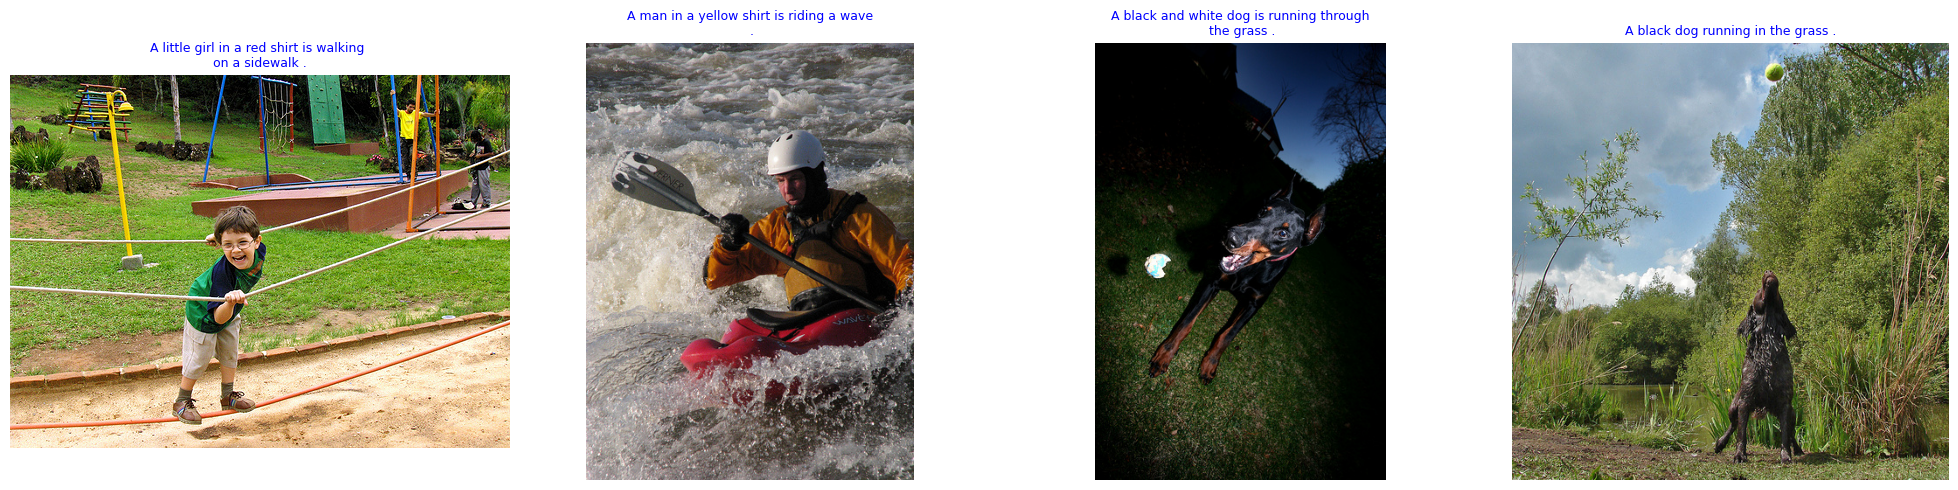

In [31]:
# --- Automatic demo: caption 4 random test-set images ---------------------
sample_names = test_df['image'].unique().tolist()
random.shuffle(sample_names)
sample_names = sample_names[:4]

fig, axes = plt.subplots(1, len(sample_names), figsize=(5 * len(sample_names), 5))
if len(sample_names) == 1:
    axes = [axes]

for ax, name in zip(axes, sample_names):
    image_path = os.path.join(images_dir, name)
    caption = generate_caption(image_path, model)
    img = Image.open(image_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("\n".join([caption[i:i+40] for i in range(0, len(caption), 40)]),
                 fontsize=9, color="blue")
    print(f"{name}: {caption}")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'inference_samples.png'), dpi=150)
plt.show()


In [25]:
# --- Upload demo: caption your own image(s) --------------------------------
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

print("Click 'Upload' to select your own image(s):")
_uploader = widgets.FileUpload(accept="image/*", multiple=True)
_btn = widgets.Button(description="Caption uploaded images", button_style="primary")
_out = widgets.Output()
display(_uploader, _btn, _out)


Click 'Upload' to select your own image(s):


FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

Button(button_style='primary', description='Caption uploaded images', style=ButtonStyle())

Output()

In [26]:
def _get_uploaded_files(upload_value):
    """Supports both ipywidgets 7 (dict) and ipywidgets 8 (tuple/list) formats."""
    if isinstance(upload_value, dict):
        for filename, file_info in upload_value.items():
            content = file_info["content"]
            content = content.tobytes() if hasattr(content, "tobytes") else bytes(content)
            yield filename, content
    else:
        for file_info in upload_value:
            filename = file_info["name"]
            content = file_info["content"]
            content = content.tobytes() if hasattr(content, "tobytes") else bytes(content)
            yield filename, content


def _on_click(_):
    with _out:
        clear_output(wait=True)
        if not _uploader.value:
            print("No images uploaded yet -- click Upload first.")
            return
        uploaded_files = list(_get_uploaded_files(_uploader.value))
        print(f"Processing {len(uploaded_files)} image(s)...")
        for fname, data in uploaded_files:
            try:
                tmp_path = os.path.join(WORK_DIR, f"_upload_{fname}")
                with open(tmp_path, "wb") as fh:
                    fh.write(data)
                caption = generate_caption(tmp_path, model)
                img = Image.open(tmp_path).convert("RGB")
                fig, ax = plt.subplots(figsize=(6, 6))
                ax.imshow(img); ax.axis("off")
                ax.set_title("\n".join([caption[i:i+50] for i in range(0, len(caption), 50)]),
                             fontsize=10, color="blue")
                plt.tight_layout(); plt.show(); plt.close(fig)
                print(f"{fname}: {caption}")
                print("-" * 60)
            except Exception as e:
                print(f"Could not process {fname}: {type(e).__name__}: {e}")

_btn.on_click(_on_click)
print("Upload widget ready -- click 'Upload', pick image(s), then 'Caption uploaded images'.")


Upload widget ready -- click 'Upload', pick image(s), then 'Caption uploaded images'.


## 8. Failure case analysis

Run this after the automatic demo above to see a few captions the model gets
noticeably wrong, alongside the human reference captions -- useful for the
write-up's analysis section.

In [27]:
sample_names_fail = test_df['image'].unique().tolist()
random.shuffle(sample_names_fail)
sample_names_fail = sample_names_fail[:4]

for name in sample_names_fail:
    image_path = os.path.join(images_dir, name)
    caption = generate_caption(image_path, model)
    refs = test_df[test_df['image'] == name]['caption'].tolist()
    refs_clean = [r.replace('<start>', '').replace('<end>', '').strip() for r in refs]
    print(f"Image: {name}")
    print(f"  Generated: {caption}")
    print(f"  Reference: {refs_clean[0]}")
    print()


Image: 310260324_7f941814bc.jpg
  Generated: A woman in a white shirt is standing in front of a crowd .
  Reference: a group of men lift their arms to signal while they look to the left .

Image: 2612608861_92beaa3d0b.jpg
  Generated: A group of people are posing for a picture .
  Reference: a group of children looking at something offcamera .

Image: 3481884992_45770ec698.jpg
  Generated: A surfer rides a wave .
  Reference: a man in a black wetsuit on a surfboard .

Image: 3737492755_bcfb800ed1.jpg
  Generated: A man in a red shirt is sitting in front of a crowd .
  Reference: a man dressed in an indian costume plays the drums .

